## Visualize BCNN results

In [1]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import *
import torch.nn.functional as F
from collections import defaultdict

In [2]:
# Set model 
#run_name = 'BCNN_ZOOP_20260106_142441_densenet121_3.pth'
run_name = 'BCNN_ZOOP_20260127_164247_densenet121_3.pth'

# Set paths
data_directory = '/data/Hier-Zooplankton'
root_directory = os.path.abspath('')
weights_path = os.path.join(root_directory,'Models_results/weights', run_name)
predictions_path = os.path.join(root_directory, 'Models_results/predictions', run_name)
metadata_path = os.path.join(root_directory, 'Models_results/environment', run_name)

In [3]:
# # Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_ids = metadata['classes'], metadata['class_ids']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']
levels = metadata['levels']

print(hyperparameters)

# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = [[] for _ in range(levels)]
y_pred = [[] for _ in range(levels)]
y_pred_original = [[] for _ in range(levels)] # including NA
y_prob = [[] for _ in range(levels)]

nones_list = [[] for _ in range(levels)]

for l in range(levels):
    y_true[l] = predictions[0][l].numpy()
    y_pred[l] = predictions[2][l].numpy()
    y_prob[l] = predictions[1][l].numpy()
    y_pred_original[l] = predictions[2][l].numpy()
    
    # Remove None Samples with missing values
    
    y_true_array = np.array(y_true[l])
    y_pred_array = np.array(y_pred[l])
    y_pred_original_array = np.array(y_pred_original[l],dtype=object)
    y_prob_array = np.array(y_prob[l])

    nones = np.where(y_true_array==-1)[0]
    nones_list[l]=nones
    
    if len(nones>0):
        y_true[l] = np.delete(y_true_array,nones)
        y_pred[l] = np.delete(y_pred_array,nones)
        y_prob[l] = np.delete(y_prob_array,nones,axis = 0)
        y_pred_original_array[nones] = None          
        y_pred_original[l] = y_pred_original_array
        
    

{'loss_fn': {'criterion': 'CrossEntropyLoss', 'alpha': [0.3333333333333333, 0.3333333333333333, 0.3333333333333333], 'thresholds': None}, 'optimizer': 'Adam', 'lr': 0.0005, 'epochs': 60, 'scheduler': {'type': 'CosineAnnealingLR', 'T_max': 50}, 'early_stopping': {'patience': 15, 'delta': 0.0005}, 'batch_size': 64}


### Train Performance

Model trained for 60 epochs.


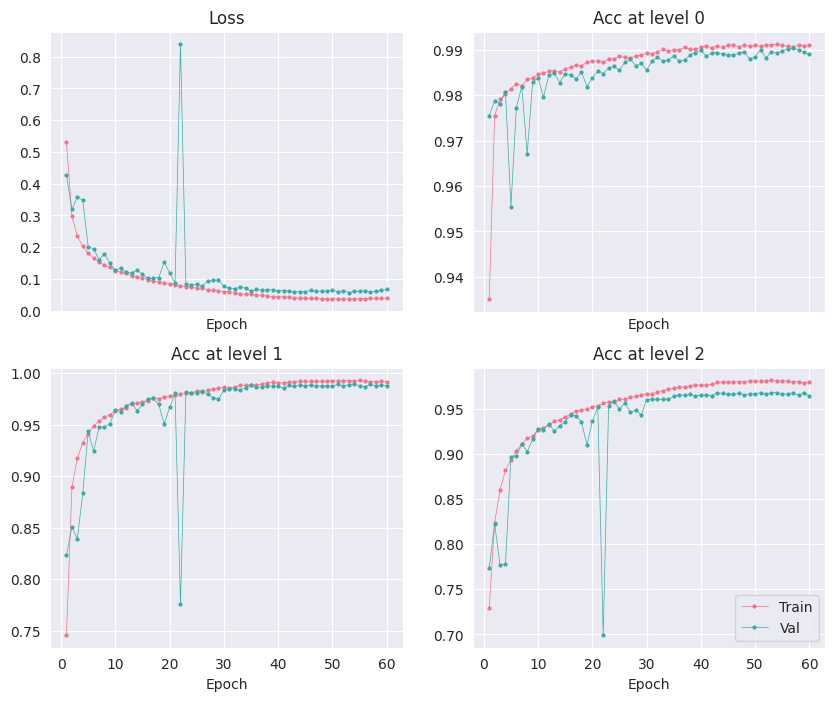

In [4]:
actual_epochs = len(train_metrics['train_acc'][0])
print(f'Model trained for {actual_epochs} epochs.')

# Plot
sns.set_style('darkgrid')
if levels == 2:
    fig, axes = plt.subplots(1, levels + 1, figsize = (14, 4), sharex = True)
elif levels == 3:
    fig, axes = plt.subplots(2, 2, figsize = (10, 8), sharex = True)
    axes = axes.flat


palette = sns.color_palette('husl', n_colors = 2)

metrics = ['loss', 'acc']
epochs_enum = list(range(1, actual_epochs+1))

indx = 0
for i, metric in enumerate(metrics):
   
    if metric == 'acc':
        for l in range(levels):
            train_values = train_metrics[f'train_{metric}'][l]
            val_values = train_metrics[f'test_{metric}'][l]

            axes[indx].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
            axes[indx].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
            
            axes[indx].set_title(metric.capitalize()+f' at level {l}')
            axes[indx].set_xlabel('Epoch')
            indx +=1
            
    else:
        train_values = train_metrics[f'train_{metric}']
        val_values = train_metrics[f'test_{metric}']

        axes[indx].plot(epochs_enum, train_values, label = f'Train', marker = 'o', markersize = 2, lw = 0.5, color = palette[0])
        axes[indx].plot(epochs_enum, val_values, label = f'Val', marker = 'o', markersize = 2, lw = 0.5, color = palette[1])
        
        axes[indx].set_title(metric.capitalize())
        axes[indx].set_xlabel('Epoch')
        indx +=1 
                
 
plt.legend()
plt.show()

### Test performance

In [5]:
# Compute overall metrics
for l in range(levels):
    acc = accuracy_score(y_true[l], y_pred[l])

    prec_avg = precision_score(y_true[l], y_pred[l], average = 'macro')
    prec_w_avg = precision_score(y_true[l], y_pred[l], average = 'weighted')

    recall_avg = recall_score(y_true[l], y_pred[l], average = 'macro')
    recall_w_avg = recall_score(y_true[l], y_pred[l], average = 'weighted')

    f1_avg = f1_score(y_true[l], y_pred[l], average = 'macro')
    f1_w_avg = f1_score(y_true[l], y_pred[l], average = 'weighted')

    ce = log_loss(y_true[l], y_prob[l])

    # Print
    print(f'Results for level: {l}\n')
    print(f'Accuracy: {acc:.4f}\n')
    print(f'Average Precision: {prec_avg:.4f}\nWeighted Precision: {prec_w_avg:.4f}\n')
    print(f'Average Recall: {recall_avg:.4f}\nWeighted Recall: {recall_w_avg:.4f}\n')
    print(f'Average F1: {f1_avg:.4f}\nWeighted F1: {f1_w_avg:.4f}\n')
    print(f'Cross Entropy: {ce:.4f}')
    print(f'----------------------------------\n')

Results for level: 0

Accuracy: 0.9895

Average Precision: 0.9900
Weighted Precision: 0.9895

Average Recall: 0.9880
Weighted Recall: 0.9895

Average F1: 0.9890
Weighted F1: 0.9894

Cross Entropy: 0.0356
----------------------------------

Results for level: 1

Accuracy: 0.9887

Average Precision: 0.9762
Weighted Precision: 0.9887

Average Recall: 0.9759
Weighted Recall: 0.9887

Average F1: 0.9760
Weighted F1: 0.9887

Cross Entropy: 0.0430
----------------------------------

Results for level: 2

Accuracy: 0.9679

Average Precision: 0.9634
Weighted Precision: 0.9679

Average Recall: 0.9531
Weighted Recall: 0.9679

Average F1: 0.9580
Weighted F1: 0.9678

Cross Entropy: 0.1059
----------------------------------



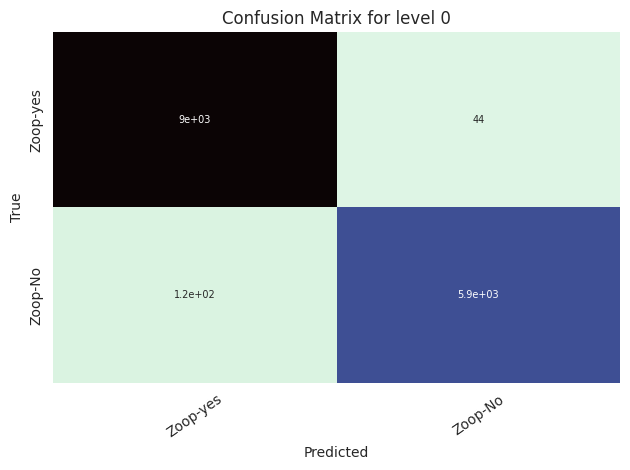

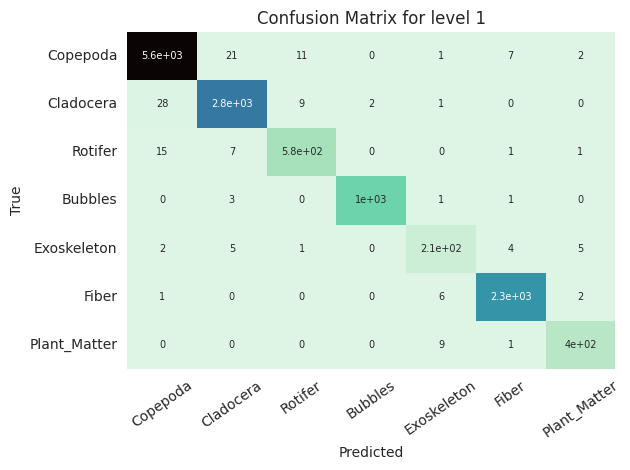

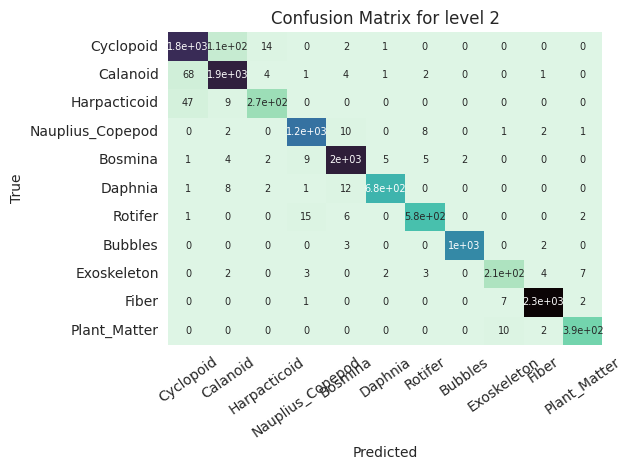

In [6]:
# Get confusion matrix data
for l in range(levels):
    cm = confusion_matrix(y_true[l], y_pred[l])
    annot_kws = {'size': 7}

    # Plot
    sns.heatmap(
        cm, annot = True, annot_kws = annot_kws, cmap = 'mako_r', 
        xticklabels = classes[l], yticklabels = classes[l], cbar = False
    )
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for level {l}')
    plt.xticks(rotation = 35)

    plt.tight_layout()
    plt.show()

### Metrics per class

In [7]:
# Compute per class metrics
precision_list = []
recall_list = []
ce_list = []

for l in range(levels):
    #clean_labels = list(filter(lambda x: x != -1, set(y_true[l])))
    precision_list.append(precision_score(y_true[l], y_pred[l], average = None))
    recall_list.append(recall_score(y_true[l], y_pred[l], average = None))

    # Cross-entropy
    y_true_tensor = torch.from_numpy(y_true[l]).long()
    y_logit_tensor = torch.from_numpy(y_prob[l]).float().log()

    ce_all = F.cross_entropy(y_logit_tensor, y_true_tensor, reduction = 'none')
    class_ces = defaultdict(list)

    for ce, y in zip(ce_all, y_true_tensor):
        class_ces[int(y)].append(ce.item())

    ce_per_class = np.full(len(classes[l]), np.nan)
    for clid in range(len(classes[l])):
        if class_ces[clid]:
            ce_per_class[clid] = np.mean(class_ces[clid])
    ce_list.append(ce_per_class)        

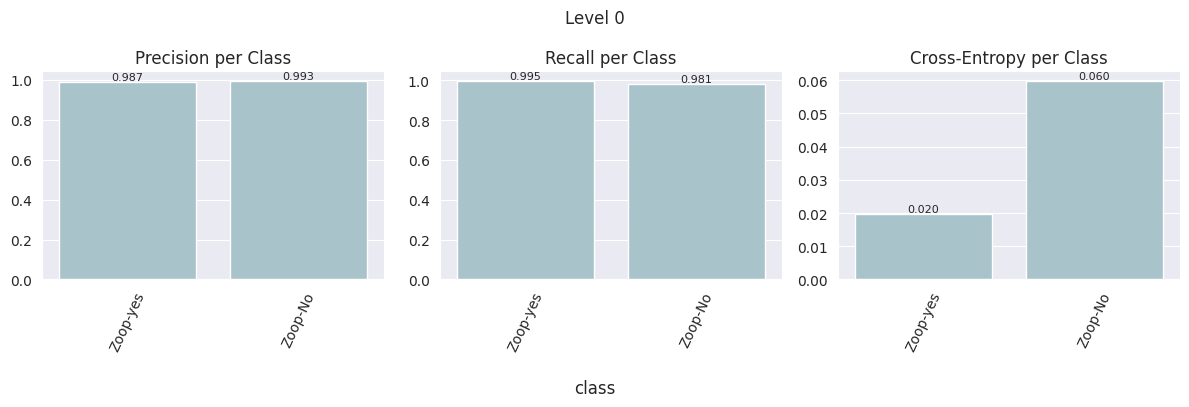

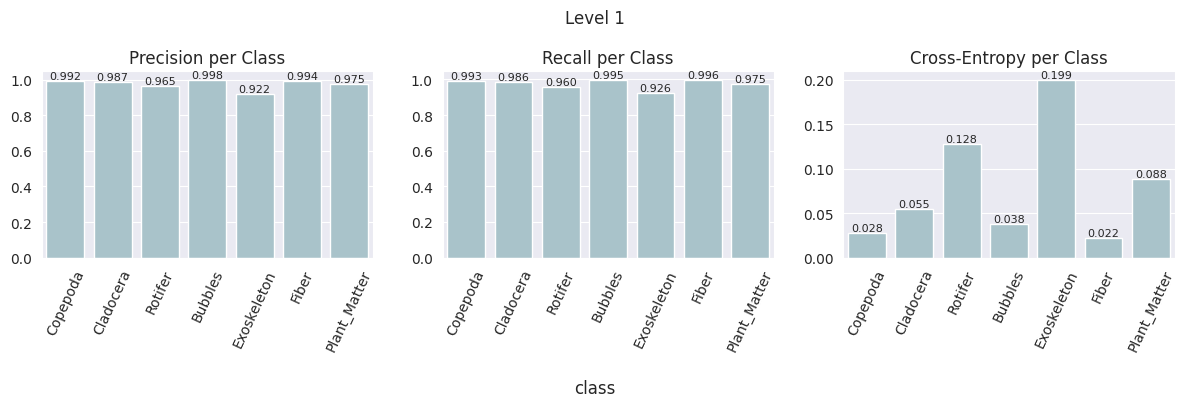

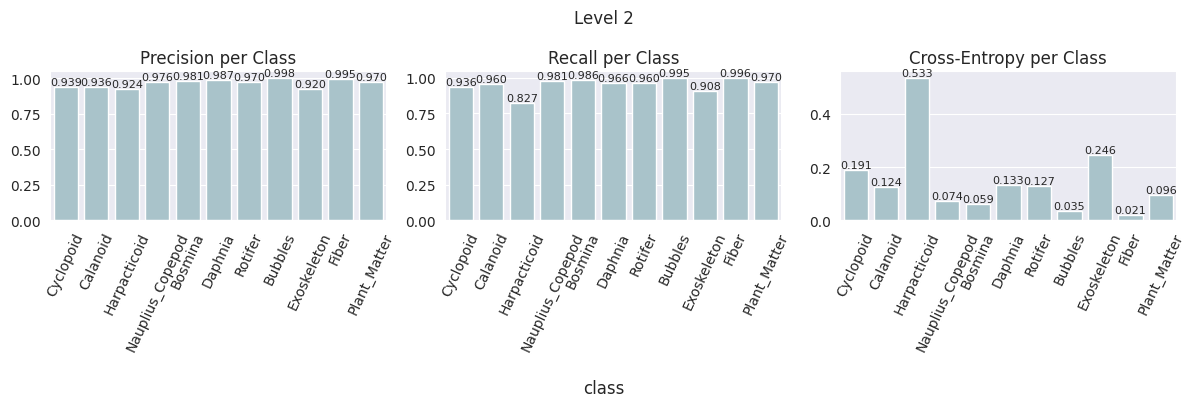

In [8]:
# Precision and Recall per class
for l in range(levels):
    sns.set_style('darkgrid')
    fig, axes = plt.subplots(1, 3, figsize = (12, 4), sharex = True)
    fig.supxlabel('class')
    fig.suptitle(f'Level {l}')
    
    # Precision
    sns.barplot(ax = axes[0],x = classes[l], y = precision_list[l], color = '#a3c6cf')
    axes[0].set_title('Precision per Class')
    axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 8)
    axes[0].tick_params(axis = 'x', rotation = 65)
    # Recall
    sns.barplot(ax = axes[1],x = classes[l], y = recall_list[l], color = '#a3c6cf')
    axes[1].set_title('Recall per Class')
    axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 8)
    axes[1].tick_params(axis = 'x', rotation = 65)
    # CE
    sns.barplot(ax = axes[2],x = classes[l], y = ce_list[l], color = '#a3c6cf')
    axes[2].set_title('Cross-Entropy per Class')
    axes[2].bar_label(axes[2].containers[0], fmt = '%.3f', fontsize = 8)
    axes[2].tick_params(axis = 'x', rotation = 65)


    plt.tight_layout()
    plt.show()

## Check for contradictions

In [18]:
preds_0 = np.array(y_pred[0])
preds_1 = np.array(y_pred[1])
preds_fn = np.array(y_pred[2])

preds_org_0 = np.array(y_pred_original[0])
preds_org_1 = np.array(y_pred_original[1])
preds_org_fn = np.array(y_pred_original[2])

level0 = classes[0]
level1 = classes[1]
final_nodes = classes[levels-1]

num_contradictions01 = [[] for _ in range(2)]
per_contradictions01 = [[] for _ in range(2)]

num_contradictions02 = [[] for _ in range(2)]
per_contradictions02 = [[] for _ in range(2)]

num_contradictions12 = [[] for _ in range(7)]
per_contradictions12 = [[] for _ in range(7)]

############### 1. Contradictions between level 0 and level 1 #################

# a. Classified as Zooplankton but contradicted the middle level

non_zooplankton_l1 = ['Bubbles','Exoskeleton','Fiber','Plant_Matter']
c_ci = level0.index('Zoop-yes') 

# Remove index with missing labels to compare
if (len(nones_list[1]))>0: 
    preds_0_compare = np.delete(preds_org_0,nones_list[1])
else:
    preds_0_compare = preds_0

for i, class_name in enumerate(non_zooplankton_l1):
    c_fi = level1.index(class_name)
    indx = np.where([preds_1 == c_fi])
    num_contradictions01[0].append(np.count_nonzero(preds_0_compare[indx[1]]== c_ci))
    per_contradictions01[0].append(
        np.count_nonzero(preds_0_compare[indx[1]]== c_ci)/len(preds_0_compare[indx[1]])
        )

# b. Classified as Non-Zooplankton but contradicted the middle level

zooplankton_l1 = ['Cladocera', 'Copepoda','Rotifer']
c_ci = level0.index('Zoop-No') 

for i, class_name in enumerate(zooplankton_l1):
    c_fi = level1.index(class_name)
    indx = np.where([preds_1 == c_fi])
    num_contradictions01[1].append(np.count_nonzero(preds_0_compare[indx[1]]== c_ci))
    per_contradictions01[1].append(
        np.count_nonzero(preds_0_compare[indx[1]]== c_ci)/len(preds_0_compare[indx[1]])
        )

############ 2. Contradictions between level 0 and final nodes #################

# a. Classified as Zooplankton but contradicted the final node

non_zooplankton_l0 = ['Bubbles','Exoskeleton','Fiber', 'Plant_Matter']
c_ci = level0.index('Zoop-yes') 

# Remove index with missing labels to compare
if (len(nones_list[2]))>0: 
    preds_0_compare = np.delete(preds_org_0,nones_list[2])
else:
    preds_0_compare = preds_0

for i, class_name in enumerate(non_zooplankton_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions02[0].append(np.count_nonzero(preds_0_compare[indx[1]]== c_ci))
    per_contradictions02[0].append(
        np.count_nonzero(preds_0_compare[indx[1]]== c_ci)/len(preds_0_compare[indx[1]])
        )
    

# b. Classified as Non-Zooplankton but contradicted the final node

zooplankton_l0 = [
    'Bosmina', 'Daphnia', 'Cyclopoid', 'Harpacticoid','Calanoid', 
    'Nauplius_Copepod','Rotifer'
    ]
c_ci = level0.index('Zoop-No') 

for i, class_name in enumerate(zooplankton_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions02[1].append(np.count_nonzero(preds_0_compare[indx[1]]== c_ci))
    per_contradictions02[1].append(
        np.count_nonzero(preds_0_compare[indx[1]]== c_ci)/len(preds_0_compare[indx[1]])
        )
    
############ 3. Contradictions between level 1 and final nodes #################

# Remove index with missing labels to compare
if (len(nones_list[2]))>0: 
    preds_1_compare = np.delete(preds_org_1,nones_list[2])
else:
    preds_1_compare = preds_1

# a. Classified as Cladocera but contradicted the final node

non_cladocera_l0 = [
    'Cyclopoid', 'Calanoid', 'Harpacticoid','Bubbles','Exoskeleton', 'Fiber',
    'Nauplius_Copepod','Rotifer', 'Plant_Matter'
    ]
c_ci = level1.index('Cladocera') 

for i, class_name in enumerate(non_cladocera_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[0].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[0].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )

# b. Classified as Copepoda but contradicted the final node

non_copepoda_l0 = [
    'Bosmina','Daphnia','Bubbles','Exoskeleton','Fiber','Rotifer','Plant_Matter'
]

c_ci = level1.index('Copepoda') 

for i, class_name in enumerate(non_copepoda_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[1].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[1].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )

# c. Classified as Rotifer but contradicted the final node

non_rotifer_l0 = [
    'Bosmina','Daphnia','Cyclopoid','Harpacticoid','Calanoid',
    'Exoskeleton','Fiber', 'Bubbles','Plant_Matter' 
]
c_ci = level1.index('Rotifer') 

for i, class_name in enumerate(non_rotifer_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[2].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[2].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )
    
# d. Classified as Bubbles but contradicted the final node

non_bubbles_l0 = [
    'Bosmina','Daphnia','Cyclopoid','Harpacticoid','Calanoid',
    'Exoskeleton','Fiber', 'Rotifer','Plant_Matter' 
]
c_ci = level1.index('Bubbles') 

for i, class_name in enumerate(non_bubbles_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[3].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[3].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )
    
# e. Classified as Exoskeleton but contradicted the final node

non_exoskeleton_l0 = [
    'Bosmina','Daphnia','Cyclopoid','Harpacticoid','Calanoid', 'Bubbles', 
    'Fiber', 'Rotifer','Plant_Matter'
]
c_ci = level1.index('Exoskeleton') 

for i, class_name in enumerate(non_exoskeleton_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[4].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[4].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )
    
# f. Classified as Fiber but contradicted the final node

non_fiber_l0 = [
    'Bosmina','Daphnia','Cyclopoid','Harpacticoid','Calanoid', 'Bubbles', 
    'Exoskeleton', 'Rotifer','Plant_Matter'
]
c_ci = level1.index('Fiber') 

for i, class_name in enumerate(non_fiber_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[5].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[5].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )
    
    

# g. Classified as Plant Matter but contradicted the final node

non_plant_matter_l0 = [
    'Bosmina','Daphnia','Cyclopoid','Harpacticoid','Calanoid', 'Bubbles', 
    'Exoskeleton', 'Rotifer','Fiber'
]
c_ci = level1.index('Plant_Matter') 

for i, class_name in enumerate(non_plant_matter_l0):
    c_fi = final_nodes.index(class_name)
    indx = np.where([preds_fn == c_fi])
    num_contradictions12[6].append(np.count_nonzero(preds_1_compare[indx[1]]== c_ci))
    per_contradictions12[6].append(
        np.count_nonzero(preds_1_compare[indx[1]]== c_ci)/len(preds_1_compare[indx[1]])
        )
    


percentage_01 = (
sum(num_contradictions01[0]) + sum(num_contradictions01[1])
)/ len(y_pred[0])
percentage_02 = (
    sum(num_contradictions02[0]) + sum(num_contradictions02[1])
    ) / len(y_pred[2])
percentage_12 = (
    sum(num_contradictions12[0]) + sum(num_contradictions12[1]) + 
    sum(num_contradictions12[2]) + sum(num_contradictions12[3]) +
    sum(num_contradictions12[4]) + sum(num_contradictions12[5]) +
    sum(num_contradictions12[6])
)/ len(y_pred[0])

print(f'Overall percentage contradictions between level 0 and 1 : {percentage_01:.4f}\n')
print(f'Overall percentage contradictions between level 0 and final nodes : {percentage_02:.4f}\n')
print(f'Overall percentage contradictions between level 1 and final nodes : {percentage_12:.4f}\n')


Overall percentage contradictions between level 0 and 1 : 0.0029

Overall percentage contradictions between level 0 and final nodes : 0.0038

Overall percentage contradictions between level 1 and final nodes : 0.0038



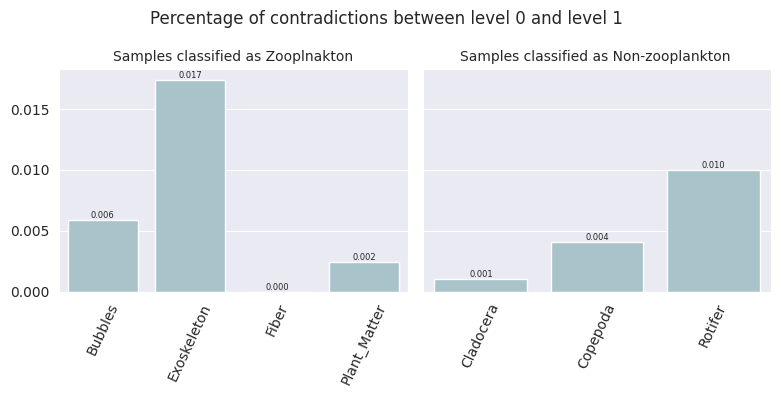

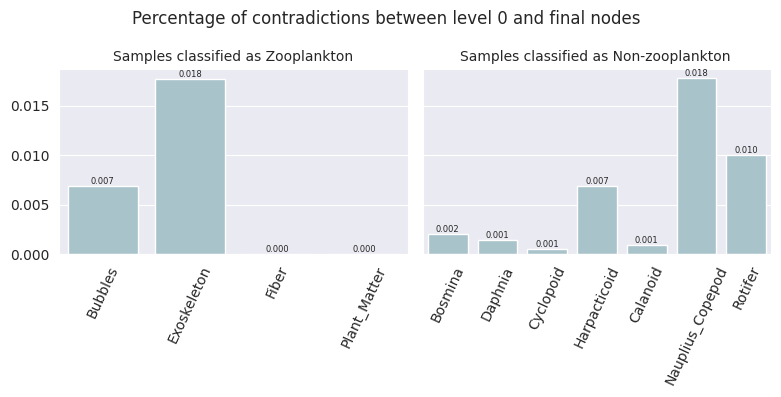

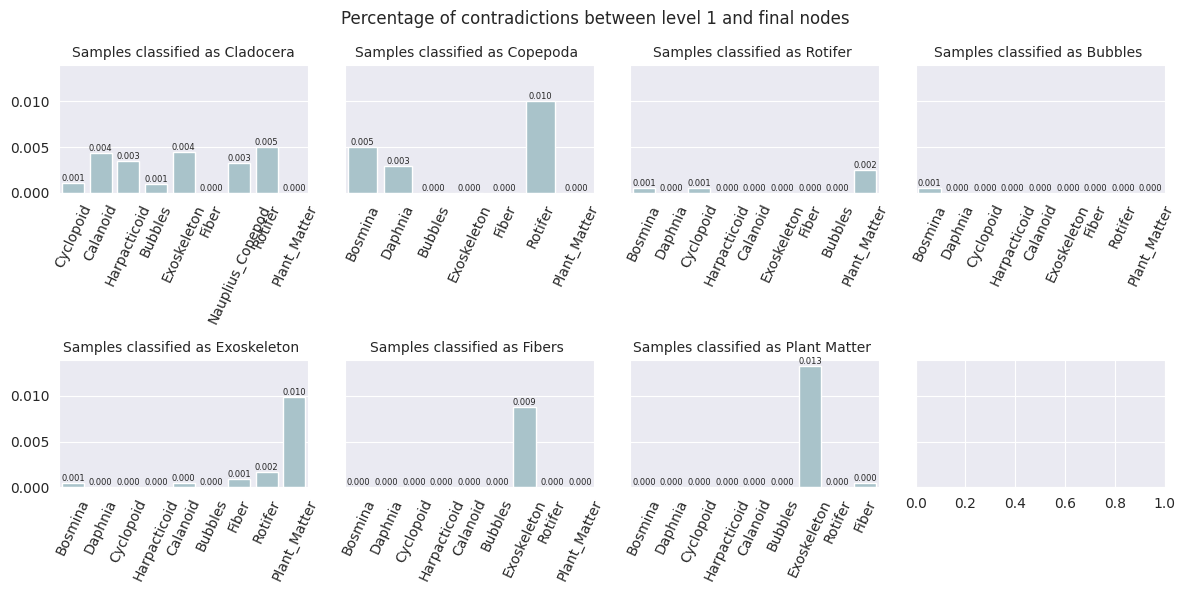

In [21]:
# Level 0 and level 1
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 2, figsize = (8, 4),sharey=True)
axes = axes.flat
fig.suptitle('Percentage of contradictions between level 0 and level 1')
sns.barplot(ax = axes[0],x = non_zooplankton_l1, y = per_contradictions01[0], color = '#a3c6cf')
axes[0].set_title('Samples classified as Zooplnakton',fontsize = 10)
axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
axes[0].tick_params(axis = 'x', rotation = 65)


sns.barplot(ax = axes[1],x = zooplankton_l1, y = per_contradictions01[1], color = '#a3c6cf')
axes[1].set_title('Samples classified as Non-zooplankton ', fontsize = 10)
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
axes[1].tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

# Level 0 and final nodes
fig, axes = plt.subplots(1, 2, figsize = (8, 4),sharey=True)
axes = axes.flat
fig.suptitle('Percentage of contradictions between level 0 and final nodes')
sns.barplot(ax = axes[0],x = non_zooplankton_l0, y = per_contradictions02[0], color = '#a3c6cf')
axes[0].set_title('Samples classified as Zooplankton',fontsize = 10)
axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
axes[0].tick_params(axis = 'x', rotation = 65)


sns.barplot(ax = axes[1],x = zooplankton_l0, y = per_contradictions02[1], color = '#a3c6cf')
axes[1].set_title('Samples classified as Non-zooplankton ', fontsize = 10)
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
axes[1].tick_params(axis = 'x', rotation = 65)

plt.tight_layout()
plt.show()

# Level 1 and final nodes
fig, axes = plt.subplots(2, 4, figsize = (12, 6),sharey=True)
axes = axes.flat
fig.suptitle('Percentage of contradictions between level 1 and final nodes')
sns.barplot(ax = axes[0],x = non_cladocera_l0, y = per_contradictions12[0], color = '#a3c6cf')
axes[0].set_title('Samples classified as Cladocera',fontsize = 10)
axes[0].bar_label(axes[0].containers[0], fmt = '%.3f', fontsize = 6)
axes[0].tick_params(axis = 'x', rotation = 65)


sns.barplot(ax = axes[1],x = non_copepoda_l0, y = per_contradictions12[1], color = '#a3c6cf')
axes[1].set_title('Samples classified as Copepoda ', fontsize = 10)
axes[1].bar_label(axes[1].containers[0], fmt = '%.3f', fontsize = 6)
axes[1].tick_params(axis = 'x', rotation = 65)

sns.barplot(ax = axes[2],x = non_rotifer_l0, y = per_contradictions12[2], color = '#a3c6cf')
axes[2].set_title('Samples classified as Rotifer ', fontsize = 10)
axes[2].bar_label(axes[2].containers[0], fmt = '%.3f', fontsize = 6)
axes[2].tick_params(axis = 'x', rotation = 65)

sns.barplot(ax = axes[3],x = non_bubbles_l0, y = per_contradictions12[3], color = '#a3c6cf')
axes[3].set_title('Samples classified as Bubbles ', fontsize = 10)
axes[3].bar_label(axes[3].containers[0], fmt = '%.3f', fontsize = 6)
axes[3].tick_params(axis = 'x', rotation = 65)

sns.barplot(ax = axes[4],x = non_exoskeleton_l0, y = per_contradictions12[4], color = '#a3c6cf')
axes[4].set_title('Samples classified as Exoskeleton ', fontsize = 10)
axes[4].bar_label(axes[4].containers[0], fmt = '%.3f', fontsize = 6)
axes[4].tick_params(axis = 'x', rotation = 65)

sns.barplot(ax = axes[5],x = non_fiber_l0, y = per_contradictions12[5], color = '#a3c6cf')
axes[5].set_title('Samples classified as Fibers ', fontsize = 10)
axes[5].bar_label(axes[5].containers[0], fmt = '%.3f', fontsize = 6)
axes[5].tick_params(axis = 'x', rotation = 65)

sns.barplot(ax = axes[6],x = non_plant_matter_l0, y = per_contradictions12[6], color = '#a3c6cf')
axes[6].set_title('Samples classified as Plant Matter ', fontsize = 10)
axes[6].bar_label(axes[6].containers[0], fmt = '%.3f', fontsize = 6)
axes[6].tick_params(axis = 'x', rotation = 65)


plt.tight_layout()
plt.show()